In [1]:
import numpy as np
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sksurv.metrics import integrated_brier_score, brier_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from lifelines.utils import concordance_index


In [2]:
df_improvement = pd.read_csv("dataset/df_clean.csv")

df_improvement["Minutes of Use"] = df_improvement["Seconds of Use"] / 60
df_improvement = df_improvement.drop(columns=["Seconds of Use"])

print(f"Shape: {df_improvement.shape}")

# Train/val/test split 70/15/15
df_study, df_test = train_test_split(
    df_improvement, test_size=0.15,
    stratify=df_improvement['Churn'], random_state=42
)
df_train, df_val = train_test_split(
    df_study, test_size=0.1765,  # 0.1765 = 15/85
    stratify=df_study['Churn'], random_state=42
)

print(f"Shape for training set:   {df_train.shape}")
print(f"Shape for validation set: {df_val.shape}")
print(f"Shape for test set:       {df_test.shape}")

df_train.to_csv("dataset/df_train.csv", index=False)
df_val.to_csv("dataset/df_val.csv", index=False)
df_test.to_csv("dataset/df_test.csv", index=False)


Shape: (2850, 14)
Shape for training set:   (1994, 14)
Shape for validation set: (428, 14)
Shape for test set:       (428, 14)


In [3]:
drop_columns = ["Subscription Length", "Churn", "Status", "Customer Value", "Age"]

parameters = {
    'objective': 'survival:aft',
    'eval_metric': 'aft-nloglik',
    'aft_loss_distribution': 'normal',
    'learning_rate': 0.01,
    'max_depth': 8,
    'min_child_weight': 10
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
# ── STEP 1: Cross-Validation ──

models      = []
best_rounds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["Churn"])):
    train_fold = df_train.iloc[train_idx]
    val_fold   = df_train.iloc[val_idx]  

    X_train = train_fold.drop(columns=drop_columns)
    dtrain  = xgb.DMatrix(X_train)
    dtrain.set_float_info('label_lower_bound', train_fold['Subscription Length'].values)
    dtrain.set_float_info('label_upper_bound', np.where(
        train_fold['Churn'] == 0, np.inf, train_fold['Subscription Length'].values))

    X_val_fold = val_fold.drop(columns=drop_columns)
    dval_fold  = xgb.DMatrix(X_val_fold)
    dval_fold.set_float_info('label_lower_bound', val_fold['Subscription Length'].values)
    dval_fold.set_float_info('label_upper_bound', np.where(
        val_fold['Churn'] == 0, np.inf, val_fold['Subscription Length'].values))

    fold_model = xgb.train(
        params=parameters,
        dtrain=dtrain,
        num_boost_round=500,
        evals=[(dtrain, 'train'), (dval_fold, 'val')],
        early_stopping_rounds=20,
        verbose_eval=10
    )
    models.append(fold_model)
    best_rounds.append(fold_model.best_iteration)
    print(f"Fold {fold+1} best round: {fold_model.best_iteration}")

avg_best_round = int(np.mean(best_rounds))
print(f"\nAverage best round across folds: {avg_best_round}")


[0]	train-aft-nloglik:11.02227	val-aft-nloglik:11.02259
[10]	train-aft-nloglik:9.30102	val-aft-nloglik:9.30508
[20]	train-aft-nloglik:7.88115	val-aft-nloglik:7.88949
[30]	train-aft-nloglik:6.70848	val-aft-nloglik:6.71982
[40]	train-aft-nloglik:5.73866	val-aft-nloglik:5.75182
[50]	train-aft-nloglik:4.93529	val-aft-nloglik:4.94899
[60]	train-aft-nloglik:4.26875	val-aft-nloglik:4.28146
[70]	train-aft-nloglik:3.71474	val-aft-nloglik:3.72671
[80]	train-aft-nloglik:3.25349	val-aft-nloglik:3.26479
[90]	train-aft-nloglik:2.86863	val-aft-nloglik:2.87914
[100]	train-aft-nloglik:2.54676	val-aft-nloglik:2.55632
[110]	train-aft-nloglik:2.27704	val-aft-nloglik:2.28630
[120]	train-aft-nloglik:2.05068	val-aft-nloglik:2.05950
[130]	train-aft-nloglik:1.86024	val-aft-nloglik:1.86854
[140]	train-aft-nloglik:1.69963	val-aft-nloglik:1.70741
[150]	train-aft-nloglik:1.56387	val-aft-nloglik:1.57136
[160]	train-aft-nloglik:1.44844	val-aft-nloglik:1.45603
[170]	train-aft-nloglik:1.35002	val-aft-nloglik:1.35773
[

In [5]:
# ── STEP 2: Train Final Model pakai full df_train ──

x_full = df_train.drop(columns=drop_columns)
d_full = xgb.DMatrix(x_full)
d_full.set_float_info('label_lower_bound', df_train['Subscription Length'].values)
d_full.set_float_info('label_upper_bound', np.where(
    df_train['Churn'] == 0, np.inf, df_train['Subscription Length'].values))

final_model = xgb.train(
    params=parameters,
    dtrain=d_full,
    num_boost_round=avg_best_round
)

print(f"Final model trained with {avg_best_round} rounds on full training set.")


Final model trained with 499 rounds on full training set.


In [6]:
# ── STEP 3: Validasi Final Model di df_val ──
X_val_final = df_val.drop(columns=drop_columns)
dval_final  = xgb.DMatrix(X_val_final)

pred_times_val = final_model.predict(dval_final)

c_index_val = concordance_index(
    event_times=df_val["Subscription Length"],
    predicted_scores=pred_times_val,
    event_observed=df_val["Churn"]
)
print(f"C-Index on Validation Set: {c_index_val:.4f}")


C-Index on Validation Set: 0.9222


In [7]:
# ── STEP 4: Save Final Model ──
final_model.save_model("model.json")
print("Model saved to model.json")
# To load:
# model = xgb.Booster()
# model.load_model("model.json")


Model saved to model.json


In [8]:
# ── STEP 5: Evaluate Final Model di df_test ──
X_test = df_test.drop(columns=drop_columns)
dtest  = xgb.DMatrix(X_test)
dtest.set_float_info('label_lower_bound', df_test['Subscription Length'].values)
dtest.set_float_info('label_upper_bound', np.where(
    df_test['Churn'] == 0, np.inf, df_test['Subscription Length'].values))

pred_times_train = final_model.predict(d_full)
c_index_train = concordance_index(
    event_times=df_train["Subscription Length"],
    predicted_scores=pred_times_train,
    event_observed=df_train["Churn"]
)

pred_times_test = final_model.predict(dtest)
c_index_test = concordance_index(
    event_times=df_test["Subscription Length"],
    predicted_scores=pred_times_test,
    event_observed=df_test["Churn"]
)

print(f"C-Index in Training:   {c_index_train:.4f}")
print(f"C-Index in Validation: {c_index_val:.4f}")
print(f"C-Index in Testing:    {c_index_test:.4f}")


C-Index in Training:   0.9516
C-Index in Validation: 0.9222
C-Index in Testing:    0.9436


<Figure size 1000x600 with 0 Axes>

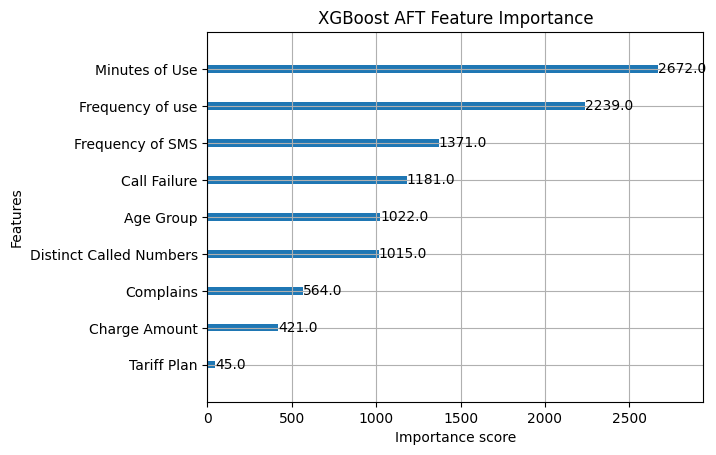

In [9]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(
    final_model,
    max_num_features=10,
    importance_type='weight',
    title='XGBoost AFT Feature Importance'
)
plt.show()


In [ ]:
# ── STEP 6: Integrated Brier Score ──
import json

y_train_surv = np.array(
    list(zip(df_train['Churn'].astype(bool), df_train['Subscription Length'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)
y_test_surv = np.array(
    list(zip(df_test['Churn'].astype(bool), df_test['Subscription Length'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)

min_time   = df_test['Subscription Length'].min()
safe_min_t = int(np.ceil(min_time))
safe_max_t = int(np.percentile(df_test['Subscription Length'], 90))
times      = np.arange(safe_min_t, safe_max_t)

# sigma must match the model's own fitted aft_loss_distribution_scale, not a guessed value,
# and the AFT model is log-normal (normal on log(time)), not normal on linear time.
with open("model.json") as f:
    _model_meta = json.load(f)
sigma = float(_model_meta["learner"]["objective"]["aft_loss_param"]["aft_loss_distribution_scale"])

surv_prob = np.zeros((len(pred_times_test), len(times)))
for i, pred_time in enumerate(pred_times_test):
    surv_prob[i, :] = norm.sf(np.log(times), loc=np.log(pred_time), scale=sigma)

ibs = integrated_brier_score(y_train_surv, y_test_surv, surv_prob, times)
print(f"Integrated Brier Score (IBS): {ibs:.4f}")


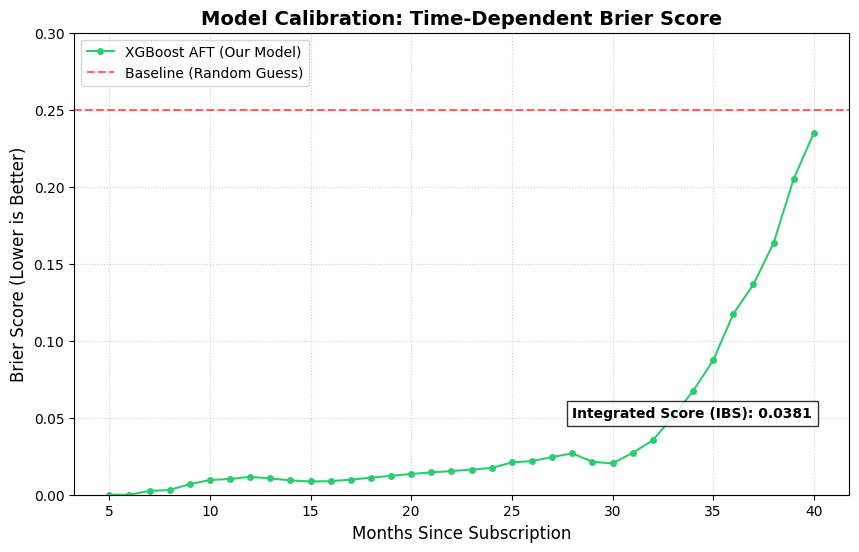

In [11]:
time_grid, brier_scores_array = brier_score(y_train_surv, y_test_surv, surv_prob, times)

plt.figure(figsize=(10, 6), dpi=100)
plt.plot(time_grid, brier_scores_array, color='#2ecc71', marker='o', markersize=4, label='XGBoost AFT (Our Model)')
plt.axhline(y=0.25, color='red', linestyle='--', alpha=0.6, label='Baseline (Random Guess)')
plt.title('Model Calibration: Time-Dependent Brier Score', fontsize=14, fontweight='bold')
plt.xlabel('Months Since Subscription', fontsize=12)
plt.ylabel('Brier Score (Lower is Better)', fontsize=12)
plt.ylim(0, 0.3)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.text(time_grid.max()*0.7, 0.05, f'Integrated Score (IBS): {ibs:.4f}',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, fontweight='bold')
plt.show()


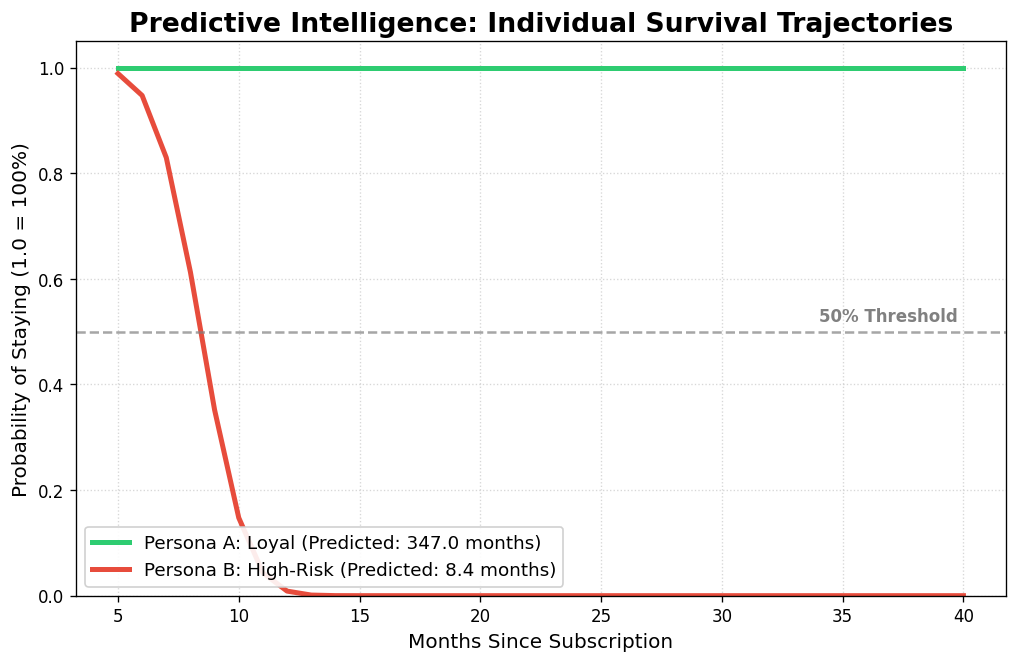

In [ ]:
loyal_idx = np.argmax(pred_times_test)
risk_idx  = np.argmin(pred_times_test)

plt.figure(figsize=(10, 6), dpi=120)
plt.plot(times, surv_prob[loyal_idx], color='#2ecc71', linewidth=3,
         label=f'Persona A: Loyal (Churn risk by month 36: {(1 - surv_prob[loyal_idx][np.argmin(np.abs(times-36))])*100:.1f}%)')
plt.plot(times, surv_prob[risk_idx], color='#e74c3c', linewidth=3,
         label=f'Persona B: High-Risk (Predicted: {pred_times_test[risk_idx]:.1f} months)')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
plt.text(times.max()*0.85, 0.52, '50% Threshold', color='gray', fontweight='bold')
plt.title('Predictive Intelligence: Individual Survival Trajectories', fontsize=16, fontweight='bold')
plt.xlabel('Months Since Subscription', fontsize=12)
plt.ylabel('Probability of Staying (1.0 = 100%)', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left', fontsize=11, framealpha=0.9)
plt.show()
